executable_path='./bin/main', system='wsl'
test.csv
Please check, where you R_dotdot read in from!
[stderr] 2026.03.19 16:49:39: (preprocess) Loaded mechanism "chemkin_kaust2023_ammonia" from "mechanism/json_files/chemkin_kaust2023_ammonia.json" in 33.58 ms. in ./src/parameters.cpp:600: get_parameters();
[stdout] test.csv

./bin/main returned with code 0 after 1.2200 seconds.


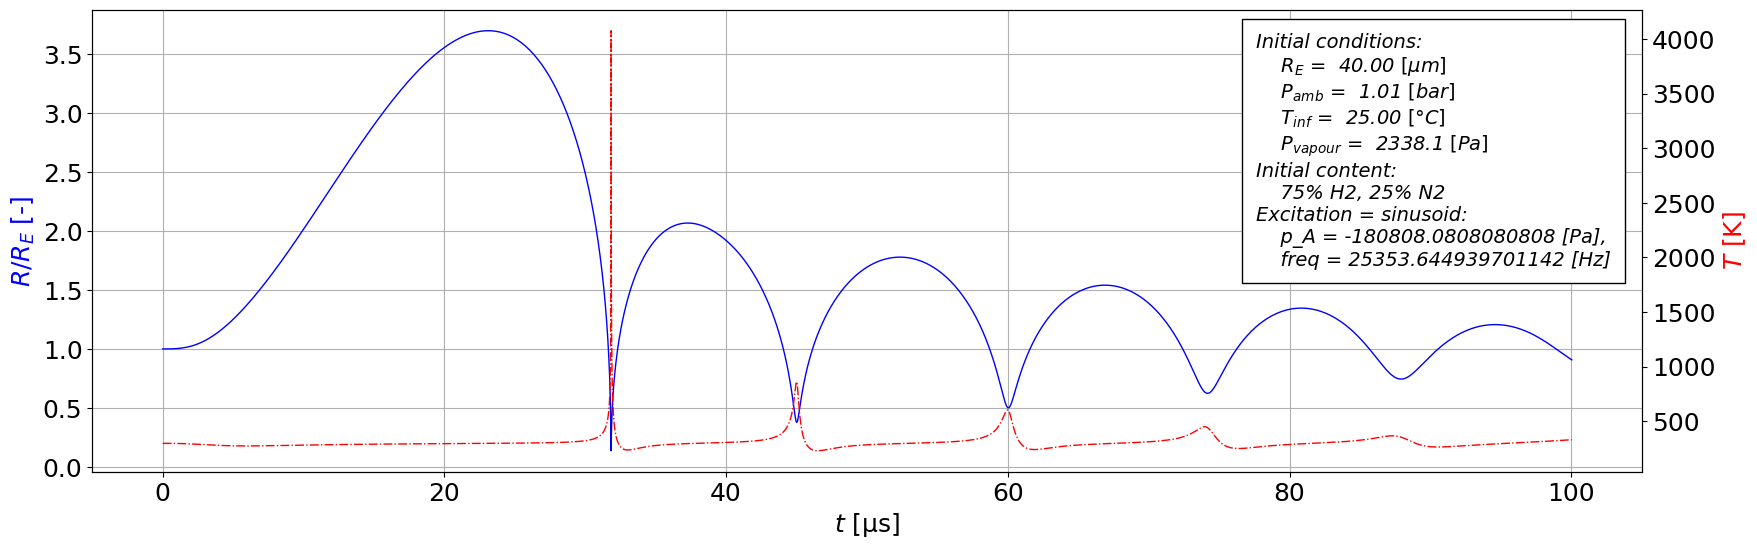

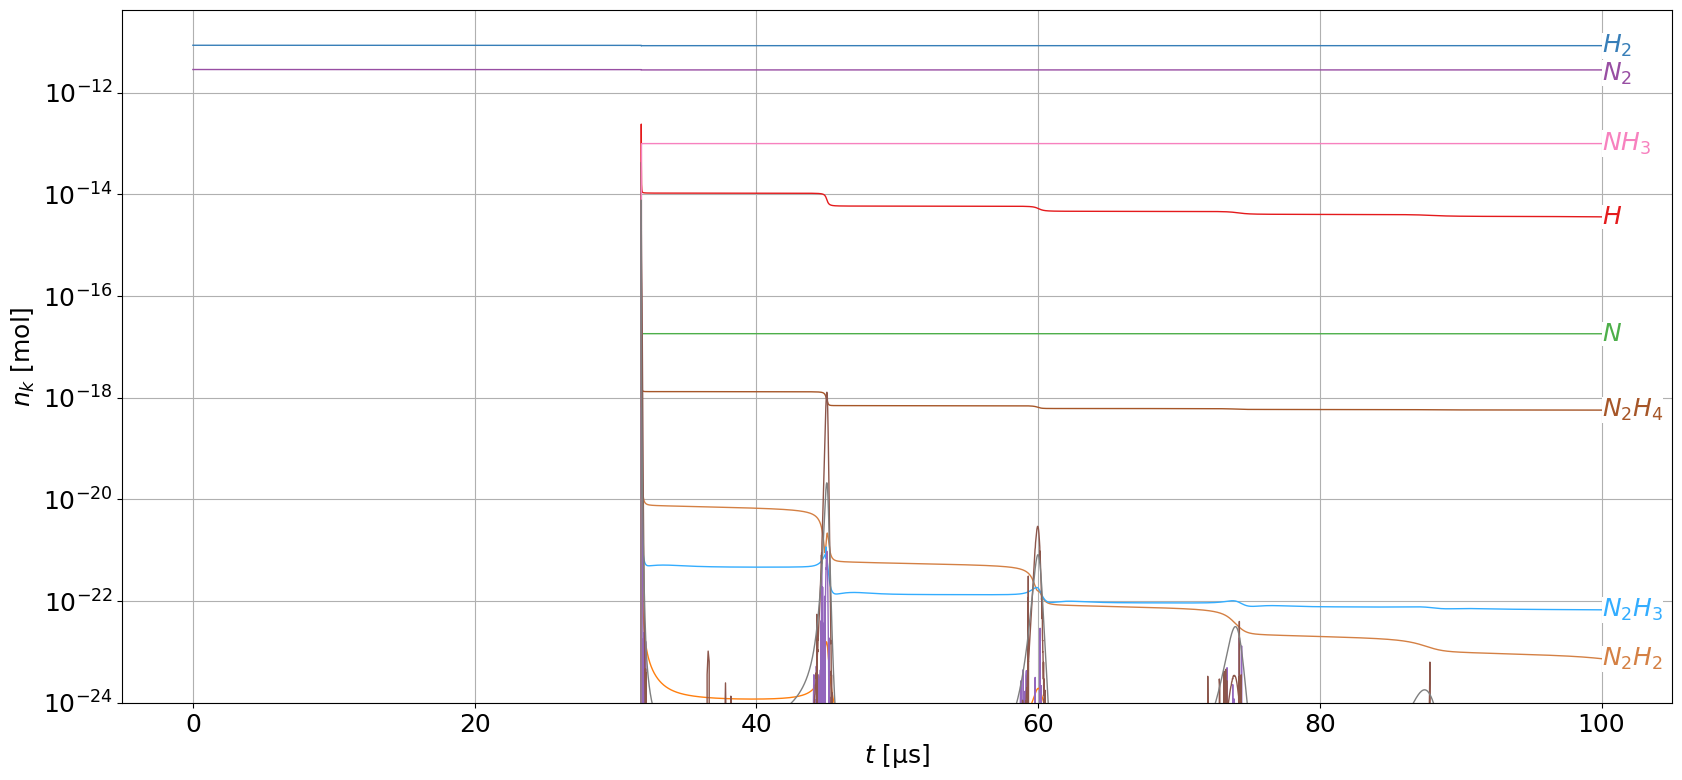

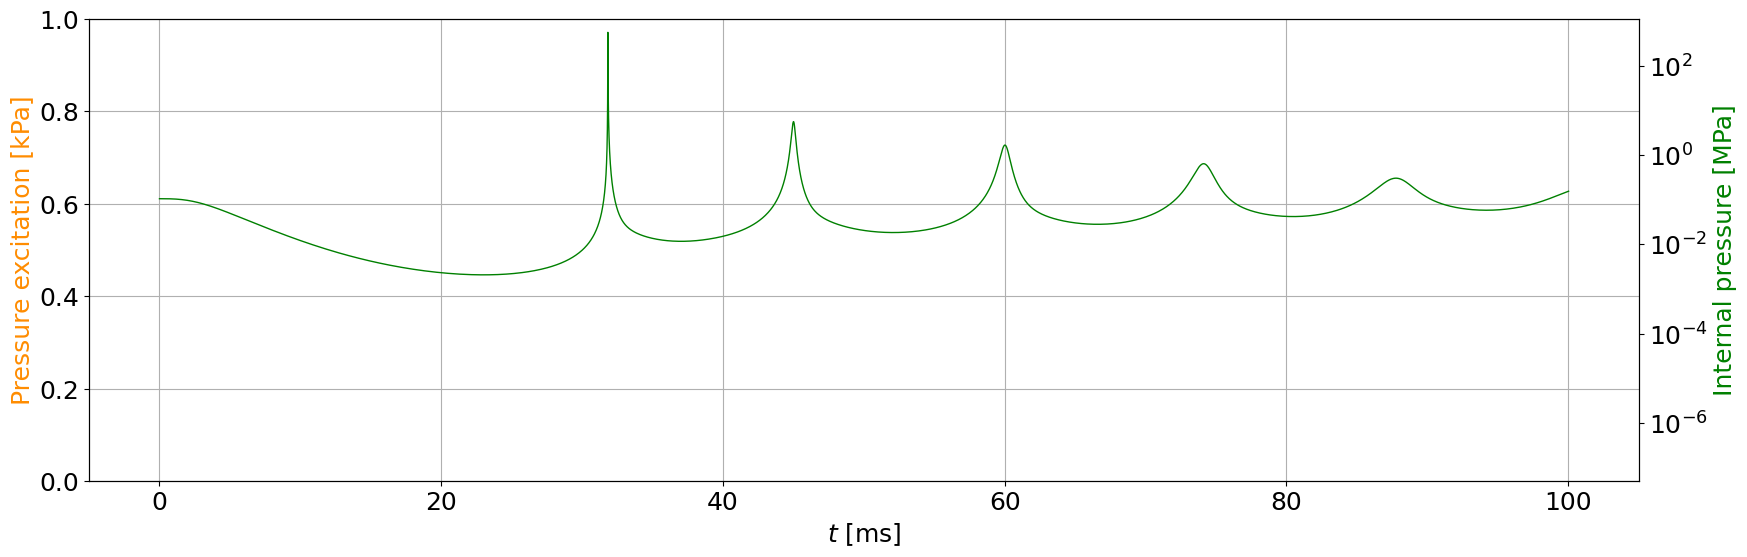

Control Parameters:
  ID: 0
  Mechanism: chemkin_kaust2023_ammonia
  R_E: 40.0 [um]
  Ratio: 1.0 [-]
  Species: ['H2', 'N2']
  Fractions: [0.75, 0.25]
  P_amb: 101325.0 [Pa]
  T_inf: 298.15 [K]
  alpha_M: 0.35 [-]
  P_v: 2338.1 [Pa]
  mu_L: 0.001 [Pa·s]
  rho_L: 998.2 [kg/m³]
  c_L: 1483.0 [m/s]
  Surfactant: 1.0
  Enable Heat Transfer: True
  Enable Evaporation: False
  Enable Reactions: True
  Enable Dissipated Energy: True
  Enable Van der Waals: True
  Enable Rate Thresholding: True
  Target Specie: NH3
  Excitation Type: sinusoid
  Excitation Params: [-180808.0808080808, 25353.644939701142]
  Excitation Cycles: 1.0 [-]
  Ramp Up Cycles: 0.0 [-]

Simulation Info:
  Success: True
  Error: 2026.03.19 16:49:40: (general, info) No error occured in ./src/common.cpp:290: get_error();
  Runtime: 1.0412399430000001 [s]
  Num Steps: 3377
  Num Repeats: 218
  Num Function Evaluations: 14458
  Num Jacobian Evaluations: 162
  t_last = 0.0001000350190742896 [s]
  R_max = 147.87917788407088 [um]

In [11]:
import importlib
from interface import python_interface as api
importlib.reload(api)
cpar=api.example_cpar()

cpar = {'ID': 0,
 'mechanism': 'chemkin_kaust2023_ammonia',
 'R_E': 40.0e-06,
 'ratio': 1.0,
 'species': ['H2','N2'],#['H2','N2','O2','AR','HE','H2O'],#['N2H3','O','NH2','NO','H'],
 'fractions': [0.75,0.25],#[0.25,0.20,0.05,0.07,0.12,0.31],#[0.3,0.25,0.2,0.15,0.1],
 'P_amb': 101325.0,
 'T_inf': 298.15,
 'alpha_M': 0.35,
 'P_v': 2338.1,
 'mu_L': 0.001,
 'rho_L': 998.2,
 'c_L': 1483.0,
 'surfactant': 1.0,
 'enable_heat_transfer': True,
 'enable_evaporation': False,
 'enable_reactions': True,
 'enable_dissipated_energy': True,
 'enable_van_der_waals': True,
 'enable_rate_thresholding': True,
 'target_specie': 'NH3',
 'excitation_type': 'sinusoid',#'sin_impulse',
 'excitation_params': [-1.808080808080808e5, 25.353644939701141e3],#[-2.12121e5, 45.4031e3],# [], 
 'excitation_cycles': 1.0,
 'ramp_up_cycles': 0.0,
 'R_and_R_dot_from_file': 0, #0: nothing to read in, chemistry is coupled to bubble dynamics; 1: R_dot is calculated here, 2: it is read from *.csv
 'rows': 1,
 'cols': 1,
 'file_name': 'test.csv', #'output_01.csv',#'output_50.csv'
 'const_V' : 0      # 0: V is not constant, 1: V is constant";
       }
print(cpar['file_name'])
print('Please check, where you R_dotdot read in from!')

data=api.run_simulation(cpar,executable_path="./bin/main",t_max=1.0e-4,timeout=300.0,save_steps=True)
#cpar: dict, json_path: str = 'ignore.json', executable_path: str = './bin/main', t_max: float = 1.0, timeout: float = 60.0, save_steps: bool = True, save_jacobian: bool = False, show_output: bool = True
api.plot(data)

ps=api.example_parameter_study()

ps['mechanism'] = 'chemkin_kaust2023_ammonia'
ps['R_E'] = {"type": "Const", "value": 0.0621}#40.0e-6}
ps['ratio'] = {"type": "Const", "value": 1.0}
ps['species'] = ['H2','N2']
ps['fractions'] = [0.75,0.25]
ps['P_amb'] =  {"type":"LinearRange","start":100.0e5,"end":600.0e5,"num_steps":6}#{"type": "Const", "value": 1.0e5}
ps['T_inf'] =  {"type":"LinearRange","start":493.15,"end":893.15,"num_steps":5}#{"type": "Const", "value": 298.15}
ps['alpha_M'] = {"type": "Const", "value": 0.35}
ps['P_v'] = {"type": "Const", "value": 2338.1}
ps['mu_L'] = {"type": "Const", "value": 0.001}
ps['rho_L'] = {"type": "Const", "value": 998.2}
ps['c_L'] = {"type": "Const", "value": 1483.0}
ps['surfactant'] = {"type": "Const", "value": 1.0}
ps['enable_heat_transfer'] = False
ps['enable_evaporation'] = False
ps['enable_reactions'] = True
ps['enable_dissipated_energy'] = True
ps['enable_van_der_waals'] = True
ps['enable_rate_thresholding'] = True
ps['target_specie'] = 'NH3'
ps['excitation_type'] = 'no_excitation'#'sinusoid'
ps['excitation_params'] = []#[
#    {"type":"LinearRange","start":-1.0e5,"end":-3.0e5,"num_steps":100},#-2.12121e5}, #p_A
#    {"type":"LogRange","start":20.0e3,"end":200.0e3,"num_steps":100}#{"type": "Const", "value": 25.0e3}#45.4031e3} #freq
#]
ps['excitation_cycles'] = {"type": "Const", "value": 1.0}
ps['ramp_up_cycles'] = {"type": "Const", "value": 0.0}
ps['R_and_R_dot_from_file'] = {"type": "Const", "value": 0.0}
ps['rows'] = {"type": "Const", "value": 1.0}
ps['cols'] = {"type": "Const", "value": 1.0}
ps['file_name'] = 'test.csv'
ps['const_V'] = 1

#api.run_parameter_study(ps,save_directory='par_study')

#datas=api.read_parameter_study('par_study1/')

#api.run_parameter_study(ps) #,save_directory='par_study'

#datas=api.read_parameter_study('par_study1/')

In [12]:
print('Please check if the data in parameters.py is correct (accurate mechanism...)!')
class dotdict(dict):
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__

import importlib   # For reloading your own files
import full_bubble_model as de
importlib.reload(de)
import parameters as par   # numeric constants and coefficents
importlib.reload(par)   # reload changes you made
file = de.Make_dir('_test', separator=',')   # it makes a folder named 'test' in which it will save data
num_sol=data['sol']
error_code=-1
elapsed_time=-1

num_sol = dotdict(data['sol'])
num_sol.y = num_sol.x.T.copy()
#num_sol.y[3:-1,:] = num_sol.y[3:-1,:]*1.0e-6#*1.0e-6: mol/m^3->mol/cm^3
#!!!! data.success = num_sol.success

data2 = de.get_data(cpar, num_sol, error_code, elapsed_time)   # post processing
file.write_solution(data2, num_sol, 'testfile')   # saving (it overwrites data)

Please check if the data in parameters.py is correct (accurate mechanism...)!
model: chemkin_kaust2023_ammonia
target specie: NH3
excitation: no_excitation (control parameters: [])
enable heat transfer: True	enable evaporation: False	enable reactions: True	enable dissipated energy: True	enable reaction rate threshold: True	enable_time_evaluation_limit: False
Folder already exists with 2 csv in it
